In [1]:
# Requires gdsfactory >= 7.x
import gdsfactory as gf
from gdsfactory import boolean
from gdsfactory.technology import LayerStack, LayerLevel
import numpy as np

In [2]:
# --- Parameters (µm) ---
WG_WIDTH_UM       = 0.8
CORE_THICKNESS    = 0.30
BOX_THICKNESS     = 2.0
CLAD_THICKNESS    = 3.0
etch_depth = 3*CORE_THICKNESS

PITCH             = 127.0                    # separation between facet endpoints
repeats = 7
straight_length = 5000
etch_lengths = [100,300,500,800,1500,2500]
etch_widths = [10,30,50]
# max_etch_length = 3000
etch_gap = [0.4,0.8,1.5,3]
# extra_length = 1000
RADIUS            = (PITCH / 2.0) - 5.8 #euler bends error             # 63.5 µm for exact 127 µm vertical offset
RADIUS_WIDE = 3*RADIUS
FACET_STRAIGHT    = 100.0                     # straight from edge before/after the bend
CHIP_W, CHIP_H    = PITCH*6*repeats, straight_length*2             # BOX & cladding rectangles

# --- Layers ---
L_WG   = (1, 0)   # core
L_BOX  = (2, 0)   # BOX (substrate)
# L_BOX_ETCH = (3,0)
L_CLAD = (3, 0)   # cladding

In [3]:


# --- Layer stack (optional, for cross-section/sims) ---
layer_stack = LayerStack(
    layers=dict(
        core=LayerLevel(layer=L_WG, thickness=CORE_THICKNESS, zmin=0.0, material="LiNbO3"),
        box=LayerLevel(layer=L_BOX, thickness=BOX_THICKNESS, zmin=-BOX_THICKNESS-etch_depth, material="SiO2"),
        # box_etch=LayerLevel(layer=L_BOX_ETCH, thickness=etch_depth, zmin=-etch_depth, material="SiO2"),
        clad=LayerLevel(layer=L_CLAD, thickness=CLAD_THICKNESS, zmin=CORE_THICKNESS, material="Air"),
    )
)

In [4]:
# --- Cross-section (LN strip) ---
xs_ln = gf.cross_section.strip(width=WG_WIDTH_UM, layer=L_WG)


In [5]:
# ---------- Cross-section ----------
xs_ln = gf.cross_section.strip(width=WG_WIDTH_UM, layer=L_WG)

# ---------- Reusable loopback builder ----------
def make_loopback_euler(straight_len: float, offset_y: float = 0.0, angle_sign: int = +1) -> gf.Component:
    """
    Builds ONE 180° Euler hairpin with radius=RADIUS.
    Places its ports on the LEFT chip edge (x = -CHIP_W/2), shifted by 'offset_y' in y.

    Args:
        straight_len: straight length before and after the 180° bend (µm)
        offset_y:     vertical offset applied to this loop (µm)
        angle_sign:   +1 => bends "up" (+180°), -1 => bends "down" (-180°)

    Returns:
        gf.Component with two ports: 'o1' (lower) and 'o2' (upper), both facing -x.
    """
    # Path: straight → 180° Euler → straight
    p = gf.path.Path()
    p += gf.path.straight(straight_len)
    p += gf.path.euler(radius=RADIUS, angle=180 * angle_sign)
    p += gf.path.straight(straight_len)
    loop = p.extrude(cross_section=xs_ln)

    c = gf.Component()
    r = c << loop

    # Place so ports lie on left chip edge, centered w.r.t the bend, then apply offset
    # For a +180° loop, the intrinsic port y's are (-R, +R). We shift by +offset_y.
    r.move((0,offset_y))

    # Expose ports
    c.add_port("o1", port=r.ports["o1"])
    c.add_port("o2", port=r.ports["o2"])
    return c

def make_wide_loopback_euler(straight_len: float, offset_y: float = 0.0, angle_sign: int = +1) -> gf.Component:
    """
    Builds ONE 180° Euler hairpin with radius=RADIUS.
    Places its ports on the LEFT chip edge (x = -CHIP_W/2), shifted by 'offset_y' in y.

    Args:
        straight_len: straight length before and after the 180° bend (µm)
        offset_y:     vertical offset applied to this loop (µm)
        angle_sign:   +1 => bends "up" (+180°), -1 => bends "down" (-180°)

    Returns:
        gf.Component with two ports: 'o1' (lower) and 'o2' (upper), both facing -x.
    """
    # Path: straight → 180° Euler → straight
    p = gf.path.Path()
    p += gf.path.straight(straight_len)
    p += gf.path.euler(radius=RADIUS_WIDE, angle=180 * angle_sign)
    p += gf.path.straight(straight_len)
    loop = p.extrude(cross_section=xs_ln)

    c = gf.Component()
    r = c << loop

    # Place so ports lie on left chip edge, centered w.r.t the bend, then apply offset
    # For a +180° loop, the intrinsic port y's are (-R, +R). We shift by +offset_y.
    r.move((0,offset_y))

    # Expose ports
    c.add_port("o1", port=r.ports["o1"])
    c.add_port("o2", port=r.ports["o2"])
    return c

gap=127
# ---------- Top level: call it thrice with your parameters ----------
@gf.cell
def ln_two_loopbacks(trench_l, trench_w, etch_gap,i) -> gf.Component:
    c = gf.Component()

    trench1 = c.add_ref(gf.components.rectangle(size=(trench_l,trench_w), layer=L_BOX))
    trench2 = c.add_ref(gf.components.rectangle(size=(trench_l,trench_w), layer=L_BOX))
    
    trench1.move((straight_length-500-trench_l,WG_WIDTH_UM/2+etch_gap))
    trench2.move((straight_length-500-trench_l,-WG_WIDTH_UM/2-etch_gap-trench_w))

    A = c << make_loopback_euler(straight_len=straight_length,  offset_y=0.0,      angle_sign=+1)
    B = c << make_wide_loopback_euler(straight_len=straight_length,  offset_y=-gap,    angle_sign=+1)
    # C = c << make_loopback_euler(straight_len=straight_length/2, offset_y=-2*gap,    angle_sign=+1)

    # Rename ports for clarity (A_o1/A_o2, etc.)
    # c.add_port("A_o1", port=A.ports["o1"]); c.add_port("A_o2", port=A.ports["o2"])
    # c.add_port("B_o1", port=B.ports["o1"]); c.add_port("B_o2", port=B.ports["o2"])
    # c.add_port("C_o1", port=C.ports["o1"]); c.add_port("C_o2", port=C.ports["o2"])

    return c

# # ---- Build & plot ----
# c = ln_three_loopbacks()
# c.plot()
# distance = abs(c.ports["C_o1"].center[1] - c.ports["C_o2"].center[1])

# print(distance)

In [6]:
import gdsfactory as gf
xs = gf.cross_section.strip(width=1.9, layer=(1,0))

def spacing_for_radius(R):
    p = gf.path.Path()
    p += gf.path.straight(100)
    p += gf.path.euler(radius=R, angle=180)
    p += gf.path.straight(100)
    c = p.extrude(cross_section=xs)
    return abs(c.ports["o2"].center[1] - c.ports["o1"].center[1])

for testR in [40, 50, 55, 56 ,57 , 57.1, 57.2, 57.3, 57.4, 57.5, 57.6, 57.7, 57.8, 57.9, 58 ,59, 60]:
    print(testR, spacing_for_radius(testR))

40 88046
50 110057
55 121063
56 123264
57 125465
57.1 125685
57.2 125906
57.3 126126
57.4 126346
57.5 126566
57.6 126786
57.7 127006
57.8 127226
57.9 127446
58 127666
59 129868
60 132069


In [7]:
# c = gf.Component("multiple loopbacks")
# count = 0

# etch_lengths = [100, 300, 500, 800, 1500, 3000]
# etch_widths  = [10, 30, 50]
# etch_gap     = [0.4, 0.8, 1.5, 3]

# c.show()
# combinations = [
#     # Special 0.4 / 0.8 gap combos for width=30, length=500 & 800
#     (300, 30, 0.4),
#     (800, 30, 0.8),
#     (800, 30, 0.4),
#     (800, 30, 0.8),

#     # Width = 10 µm
#     (100, 10, 1.5),
#     (300, 10, 3),
#     (500, 10, 1.5),
#     (800, 10, 3),
#     (1500, 10, 1.5),
#     (3000, 10, 3),

#     # Width = 30 µm (skipping 500 & 800)
#     (100, 30, 3),
#     (300, 30, 1.5),
#     (1500, 30, 3),
#     (3000, 30, 1.5),

#     # Width = 50 µm
#     (100, 50, 1.5),
#     (300, 50, 3),
#     (500, 50, 1.5),
#     (800, 50, 3),
#     (1500, 50, 1.5),
#     (3000, 50, 3),
# ]

# # ---- 1) Explicit special combos (4 total) ----
# special_combos = [
#     (300, 30, 0.4),
#     (300, 30, 0.8),
#     (800, 30, 0.4),   # change 800 -> 1000 if you add 1000 to etch_lengths
#     (800, 30, 0.8),
# ]

# for L, W, G in special_combos:
#     sub = c << ln_two_loopbacks(
#         L,
#         W,
#         G,
#         count
#     )
#     sub.move((0, -4 * gap * count))
#     count += 1

# # ---- 2) Main sweep: all other width/length combos with gaps 1.5 / 3 ----
# for j, W in enumerate(etch_widths):
#     for i, L in enumerate(etch_lengths):

#         # skip the special pairs (500,30) and (800,30)
#         if W == 30 and L in (500, 800):
#             continue

#         # alternate between gap 1.5 (index 2) and 3 (index 3)
#         gap_idx = 2 if (i + j) % 2 == 0 else 3

#         sub = c << ln_two_loopbacks(
#             L,
#             W,
#             etch_gap[gap_idx],
#             count
#         )
#         sub.move((0, -4 * gap * count))
#         count += 1

# c.plot()
# print("Total structures:", count)


Total structures: 21


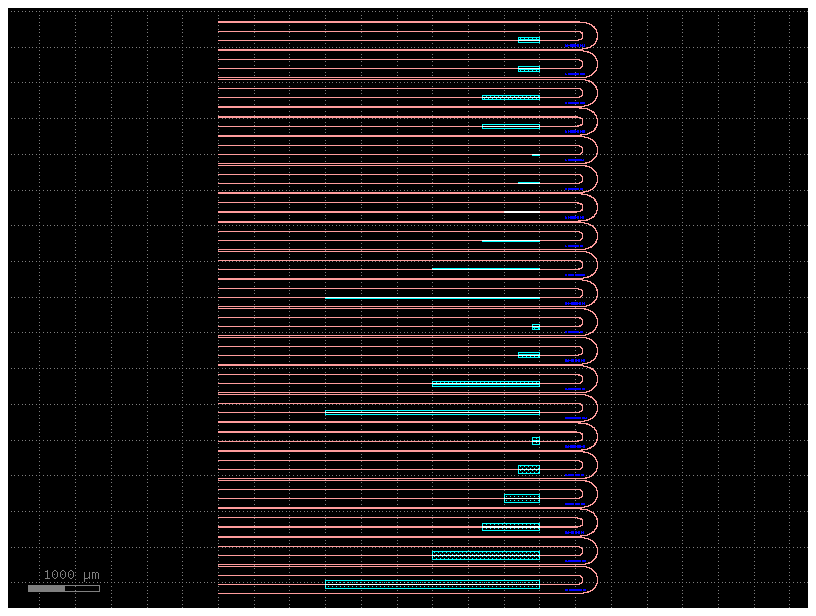

In [8]:
c = gf.Component("multiple loopbacks")
count = 1

etch_lengths = [100, 300, 500, 800, 1500, 3000]
etch_widths  = [10, 30, 50]
etch_gap     = [0.4, 0.8, 1.5, 3]

LABEL_LAYER = (10, 0)    # MUST be a fabricated layer
LABEL_SIZE = 20          # µm text height
LABEL_OFFSET = 80        # vertical offset for visibility

# ---- 1) Explicit special combos (4 total) ----
special_combos = [
    (300, 30, 0.4),
    (300, 30, 0.8),
    (800, 30, 0.4),
    (800, 30, 0.8),
]

for L, W, G in special_combos:

    sub = c << ln_two_loopbacks(L, W, G, count)
    sub.move((0, -3 * gap * count - 20*count))

    # ---- Printed text label (polygons on chip) ----
    label_text = f"{count}: L={L} W={W} G={G}"
    txt = gf.components.text(
        text=label_text,
        size=LABEL_SIZE,
        layer=LABEL_LAYER,
    )
    txt_ref = c << txt
    txt_ref.move((sub.x + 2200, sub.y - 150))

    count += 1


# ---- 2) Main sweep: all other width/length combos with gaps 1.5 / 3 ----
for j, W in enumerate(etch_widths):
    for i, L in enumerate(etch_lengths):

        # skip the special pairs
        if W == 30 and L in (500, 800):
            continue

        # alternating gap selection
        gap_idx = 2 if (i + j) % 2 == 0 else 3
        G = etch_gap[gap_idx]

        sub = c << ln_two_loopbacks(L, W, G, count)
        sub.move((0, -3 * gap * count - 20*count))

        # ---- Printed text label (polygons on chip) ----
        label_text = f"{count}: L={L} W={W} G={G}"
        txt = gf.components.text(
            text=label_text,
            size=LABEL_SIZE,
            layer=LABEL_LAYER,
        )
        txt_ref = c << txt
        txt_ref.move((sub.x + 2200, sub.y  - 150))

        count += 1


c.plot()
print("Total structures:", count)


In [9]:
c.show()

2025-12-10 16:45:44.096 | INFO     | kfactory.kcell:show:8783 - klive v0.3.3: Reloaded file 'C:\Users\PRAVAL~1\AppData\Local\Temp\4020511028.gds'


In [10]:
# @gf.cell
# def one_loopback_connected(trench_l, i) -> gf.Component:
#     c = gf.Component()

#     trench1 = c.add_ref(gf.components.rectangle(size=(trench_l,3*WG_WIDTH_UM), layer=L_BOX))
#     trench2 = c.add_ref(gf.components.rectangle(size=(trench_l,3*WG_WIDTH_UM), layer=L_BOX))
#     trench3 = c.add_ref(gf.components.rectangle(size=(3*WG_WIDTH_UM, 7*WG_WIDTH_UM), layer=L_BOX))
    
#     trench1.move((straight_length-100-trench_l,3.5*WG_WIDTH_UM))
#     trench2.move((straight_length-100-trench_l,-6.5*WG_WIDTH_UM))
#     trench3.move((straight_length-100-3*WG_WIDTH_UM, -3.5*WG_WIDTH_UM))

#     A = c << make_loopback_euler(straight_len=straight_length,  offset_y=0.0,      angle_sign=+1)

#     return c

In [11]:
# # for i in range(repeats):

# #     sub_connected = c <<  one_loopback_connected(etch_lengths[i], i)
# #     sub_connected.move((0, -(4 + 8*i) * gap))


# last_wg = c << make_loopback_euler(straight_len=straight_length/2,  offset_y=0.0,      angle_sign=+1)
# last_wg.move((0, -(4*(count)-2) * gap))


In [12]:
# c.plot()
# c.show()
# print(count)